# Szakdolgozat - Kis háló implementálása, kvantálása, és a súlyok kimentése

Ebben a Notebookban gyűjtöm össze az első heti munkámat.

## Fix méretű háló megvalósítása

Első lépésben egy kis, fixméretű hálót implementáltam és kvantáltam.

### Floating point model

A kiindulási háló FP32-vel

In [1]:
import torch
import torch.nn as nn
import numpy as np
import torch.optim as optim
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
import yaml
import matplotlib.cm as cm

class RGBClassifierNN(nn.Module):
    def __init__(self, HIDDEN_LAYER_1=4, HIDDEN_LAYER_2=4):
        super(RGBClassifierNN, self).__init__()
        self.fc1 = nn.Linear(3, HIDDEN_LAYER_1, bias=True)
        self.fc2 = nn.Linear(HIDDEN_LAYER_1, HIDDEN_LAYER_2, bias=True)
        self.fc3 = nn.Linear(HIDDEN_LAYER_2, 1, bias=True)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.sigmoid(self.fc3(x))
        return x
    
    def classify_image(self, image_path, output_path="output_heatmap.png", cmap_name="inferno"):

        self.eval()

        img = Image.open(image_path).convert('RGB')
        img_array = np.array(img, dtype=np.float32)
        img_array = (img_array - 127.5) / 127.5

        height, width, _ = img_array.shape
        output_array = np.zeros((height, width), dtype=np.float32)

        with torch.no_grad():
            for i in range(height):
                for j in range(width):
                    pixel = torch.tensor(img_array[i, j], dtype=torch.float32).unsqueeze(0).to("cuda")
                    output = self.forward(pixel).item()
                    output_array[i, j] = output
        
        # opcionalis
        output_array = np.clip(output_array, 0.0, 1.0)

        cmap = cm.get_cmap(cmap_name)
        heatmap = cmap(output_array)[:, :, :3]

        heatmap_img = Image.fromarray((heatmap * 255).astype(np.uint8))
        heatmap_img.save(output_path)

        print(f"[INFO] Hőtérkép elmentve ide: {output_path}")

        return output_array


A képek feldolgozása és a tanítóhalmaz definiálása:

In [2]:
from PIL import Image

def process_image(image_path, label, white_correction=True):
    image = np.array(Image.open(image_path).convert("RGB"))
    if white_correction:
        mask = np.all(image != [255, 255, 255], axis=-1)
    return np.column_stack((image[mask], np.full(mask.sum(), label, dtype=np.uint8)))

def prepare_data(image1_path, image2_path, white_correction=True, test_size=10000):
    data = np.vstack([process_image(image1_path, 0, white_correction)] + [process_image(image2_path, 1, white_correction)] * 80)
    np.random.shuffle(data)
    data = data.astype(np.float32)
    data = np.array(data, dtype=np.float32)

    X = (data[:, :3]) / 256.0
    y = data[:, 3].reshape(-1, 1)

    if test_size > len(X):
        test_size = len(X)

    X_remaining, X_test, y_remaining, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_remaining, y_remaining, test_size=0.2, random_state=42, stratify=y_remaining
    )

    X_train = torch.tensor(X_train, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.float32)

    X_val = torch.tensor(X_val, dtype=torch.float32)
    y_val = torch.tensor(y_val, dtype=torch.float32)

    X_test = torch.tensor(X_test, dtype=torch.float32)
    y_test = torch.tensor(y_test, dtype=torch.float32)

    return X_train, y_train, X_val, y_val, X_test, y_test

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
image1_path = "./files/street_B_sarga_nelkul.bmp"
image2_path = "./files/street_B_sarga.bmp"
image3_path = "./files/street_B.bmp"
X_train, y_train, X_val, y_val, X_test, y_test = prepare_data(image1_path, image2_path)

/tmp/ipykernel_100093/1024780219.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  image = np.array(Image.open(image_path).convert("RGB"))


Tanításhoz és a teszteléshez szükséges függvény:

In [3]:
def display_loss_plot(losses, title="Training loss", xlabel="Iterations", ylabel="Loss"):
    x_axis = [i for i in range(len(losses))]
    plt.plot(x_axis,losses)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()


def load_config(config_path="config.yaml"):
    with open(config_path, "r") as f:
        return yaml.safe_load(f)

def get_criterion(name: str):
    if name == "BCELoss":
        return nn.BCELoss()
    elif name == "BCEWithLogitsLoss":
        return nn.BCEWithLogitsLoss()
    elif name == "CrossEntropyLoss":
        return nn.CrossEntropyLoss()
    elif name == "MSELoss":
        return nn.MSELoss()
    else:
        raise ValueError(f"Unknown criterion: {name}")

def get_optimizer(name: str, model_params, lr, weight_decay=0.0, momentum=0.0):
    if name == "Adam":
        return optim.Adam(model_params, lr=lr, weight_decay=weight_decay)
    elif name == "AdamW":
        return optim.AdamW(model_params, lr=lr, weight_decay=weight_decay)
    elif name == "SGD":
        return optim.SGD(model_params, lr=lr, momentum=momentum, weight_decay=weight_decay)
    elif name == "RMSprop":
        return optim.RMSprop(model_params, lr=lr, momentum=momentum, weight_decay=weight_decay)
    else:
        raise ValueError(f"Unknown optimizer: {name}")

def train_model(model, X_train, y_train, X_val, y_val, config_path="config.yaml"):
    config = load_config(config_path)
    params = config["learning_params"]

    # paraméterek beolvasása
    learning_rate = params["learning_rate"]
    criterion = get_criterion(params["criterion"])
    optimizer = get_optimizer(params["optimizer"], model.parameters(),
                              lr=learning_rate,
                              weight_decay=params.get("weight_decay", 0.0),
                              momentum=params.get("momentum", 0.0))
    epochs = params["num_of_epochs"]
    patience = params.get("patience", 50)
    early_stopping_threshold = params.get("early_stopping_threshold", 0.001)
    device = torch.device(params.get("device", "cuda" if torch.cuda.is_available() else "cpu"))

    X_train = X_train.clone().detach().float().to(device)
    y_train = y_train.clone().detach().float().to(device)
    X_val = X_val.clone().detach().float().to(device)
    y_val = y_val.clone().detach().float().to(device)
    model.to(device)
    criterion = criterion.to(device)

    train_losses = []
    val_losses = []
    epochs_since_improvement = 0 
    best_val_loss = float("inf")

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val)
            val_loss = criterion(val_outputs, y_val)

        train_losses.append(loss.item())
        val_losses.append(val_loss.item())
        
        if epoch % 50 == 0:
            print(f"Epoch {epoch}, Train Loss: {loss.item():.6f}, Val Loss: {val_loss.item():.6f}")
        if val_loss < best_val_loss - early_stopping_threshold:
            best_val_loss = val_loss
            epochs_since_improvement = 0
        else:
            epochs_since_improvement += 1

        if epochs_since_improvement >= patience:
            print(f"Early stopping at epoch {epoch}.")
            break
    
    loss_per_epoch = [np.mean(loss_per_epoch) for loss_per_epoch in train_losses]
    display_loss_plot(loss_per_epoch)

    return model

from typing import Tuple, Dict

def test(model: nn.Module, X: torch.Tensor, y: torch.Tensor, threshold: float = 0.5, total_iterations: int = None) -> Dict[str, float]:
    TP = TN = FP = FN = 0
    total = 0
    model.eval()
    
    with torch.no_grad():
        max_samples = len(X) if total_iterations is None else min(len(X), total_iterations)
        for i in range(max_samples):
            x_i = X[i].unsqueeze(0)
            y_i = y[i].item()
            output = model(x_i).item()
            pred = 1 if output >= threshold else 0
            
            if pred == 1 and y_i == 1:
                TP += 1
            elif pred == 0 and y_i == 0:
                TN += 1
            elif pred == 1 and y_i == 0:
                FP += 1
            elif pred == 0 and y_i == 1:
                FN += 1
                
            total += 1

            if i % 1000 == 0 and i > 0:
                print(f"Processed {i} samples...")
    
    accuracy = (TP + TN) / total if total > 0 else 0
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    
    print(f'TP={TP}, TN={TN}, FP={FP}, FN={FN}')
    print(f'Accuracy: {round(accuracy, 8)}')
    print(f'Precision: {round(precision, 8)}')
    print(f'Recall: {round(recall, 8)}')
    print(f'F1-Score: {round(f1_score, 8)}')
    print(f'Specificity: {round(specificity, 8)}')
    
    results = {
        'accuracy': round(accuracy, 8),
        'precision': round(precision, 8),
        'recall': round(recall, 8),
        'f1_score': round(f1_score, 8),
        'specificity': round(specificity, 8),
        'confusion_matrix': {
            'TP': TP,
            'TN': TN, 
            'FP': FP,
            'FN': FN
        }
    }
    
    return results

Tanítás:

Epoch 0, Train Loss: 0.694922, Val Loss: 0.691509
Epoch 50, Train Loss: 0.424852, Val Loss: 0.415308
Epoch 100, Train Loss: 0.042314, Val Loss: 0.040561
Epoch 150, Train Loss: 0.012098, Val Loss: 0.012247
Epoch 200, Train Loss: 0.009719, Val Loss: 0.009990
Epoch 250, Train Loss: 0.008897, Val Loss: 0.009183
Epoch 300, Train Loss: 0.008224, Val Loss: 0.008497
Epoch 350, Train Loss: 0.007792, Val Loss: 0.008064
Early stopping at epoch 396.


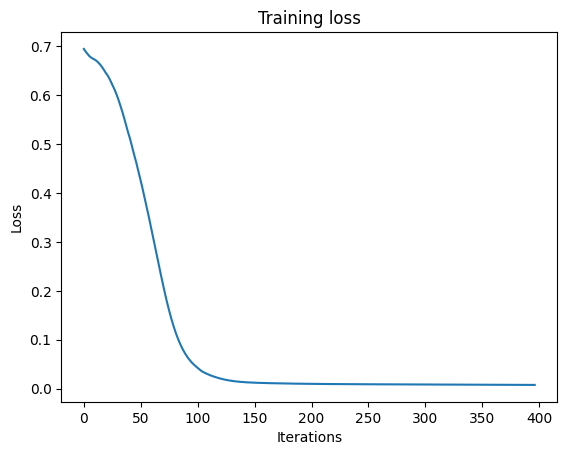

Processed 1000 samples...
Processed 2000 samples...
Processed 3000 samples...
Processed 4000 samples...
Processed 5000 samples...
Processed 6000 samples...
Processed 7000 samples...
Processed 8000 samples...
Processed 9000 samples...
TP=4779, TN=5202, FP=11, FN=8
Accuracy: 0.9981
Precision: 0.99770355
Recall: 0.99832881
F1-Score: 0.99801608
Specificity: 0.99788989


In [5]:
floating_point_model = RGBClassifierNN()
floating_point_model = train_model(floating_point_model, X_train, y_train, X_val, y_val)
report = test(floating_point_model.to("cpu"), X_test, y_test)

### Kvantált háló - PyTorch-ban

Az implementáció megegyezik a floating pointos modellel, azzal a különbséggel, hogy a háló elejére egy olyan réteget rak, ami az inputot FP32-ről INT8-ra kvantálja, és a végére egy másik réteget, ami INT8-ból alakítja vissza a kimenetet FP32-re.

In [6]:
class QuantRGBClassifierNN(nn.Module):    
    def __init__(self, HIDDEN_LAYER_1=4, HIDDEN_LAYER_2=4):
        super(QuantRGBClassifierNN, self).__init__()
        self.quant = torch.quantization.QuantStub()
        self.fc1 = nn.Linear(3, HIDDEN_LAYER_1, bias=True)
        self.fc2 = nn.Linear(HIDDEN_LAYER_1, HIDDEN_LAYER_2, bias=True)
        self.fc3 = nn.Linear(HIDDEN_LAYER_2, 1, bias=True)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.dequant = torch.quantization.DeQuantStub()

    def forward(self, x):
        x = self.quant(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.sigmoid(self.fc3(x))
        x = self.dequant(x)
        return x
    
    def classify_image(self, image_path, output_path="output_quant_heatmap.png", cmap_name="inferno"):

        self.eval()

        img = Image.open(image_path).convert('RGB')
        img_array = np.array(img, dtype=np.float32)
        img_array = (img_array - 127.5) / 127.5 

        height, width, _ = img_array.shape
        output_array = np.zeros((height, width), dtype=np.float32)

        with torch.no_grad():
            for i in range(height):
                for j in range(width):
                    pixel = torch.tensor(img_array[i, j], dtype=torch.float32).unsqueeze(0).to("cuda")
                    output = self.forward(pixel).item()
                    output_array[i, j] = output

        output_array = np.clip(output_array, 0.0, 1.0)

        cmap = cm.get_cmap(cmap_name)
        heatmap = cmap(output_array)[:, :, :3]

        heatmap_img = Image.fromarray((heatmap * 255).astype(np.uint8))
        heatmap_img.save(output_path)

        print(f"[INFO] Hőtérkép elmentve ide: {output_path}")

        return output_array

Itt valósul meg a kvantált háló példűnyosítása, és kalibrálása (a tesztadatokkal), valamint a tesztelése

In [7]:
quant_model = QuantRGBClassifierNN().to(device="cpu")
quant_model.load_state_dict(floating_point_model.state_dict())
quant_model.eval()

quant_model.qconfig = torch.ao.quantization.default_qconfig
quant_model = torch.ao.quantization.prepare(quant_model, inplace=True)

# print(quant_model)
X_test.to("cuda")
y_test.to("cuda")
test(quant_model, X_test, y_test)
quant_model = torch.ao.quantization.convert(quant_model, inplace=True)
# print(quant_model)

Processed 1000 samples...
Processed 2000 samples...
Processed 3000 samples...
Processed 4000 samples...
Processed 5000 samples...
Processed 6000 samples...
Processed 7000 samples...
Processed 8000 samples...
Processed 9000 samples...
TP=4779, TN=5202, FP=11, FN=8
Accuracy: 0.9981
Precision: 0.99770355
Recall: 0.99832881
F1-Score: 0.99801608
Specificity: 0.99788989


### Brevitas PTQ kvantálás

A háló definiálása nagyon hasonló az eddigiekhez, azt leszámítva, hogy a súlyok és aktivációk külön paraméterekkel kvantálhatóak.

In [8]:
import brevitas.nn as qnn
from brevitas.quant import Int8WeightPerTensorFixedPoint, Int8ActPerTensorFixedPoint, Int8BiasPerTensorFixedPointInternalScaling

class QuantRGBClassifierNN_Brevitas(nn.Module):
    def __init__(self, HIDDEN_LAYER_1=4, HIDDEN_LAYER_2=4, act_quant=Int8ActPerTensorFixedPoint, weight_quant=Int8WeightPerTensorFixedPoint):
        super(QuantRGBClassifierNN_Brevitas, self).__init__()

        self.quant_input = qnn.QuantIdentity(
            act_quant=act_quant,
        )

        self.fc1 = qnn.QuantLinear(
            in_features=3,
            out_features=HIDDEN_LAYER_1,
            weight_quant=weight_quant,
            bias=True,
            bias_quant=Int8BiasPerTensorFixedPointInternalScaling,
        )
        
        self.fc2 = qnn.QuantLinear(
            in_features=HIDDEN_LAYER_1, 
            out_features=HIDDEN_LAYER_2,
            weight_quant=weight_quant,
            bias=True,
            bias_quant=Int8BiasPerTensorFixedPointInternalScaling,
        )
        
        self.fc3 = qnn.QuantLinear(
            in_features=HIDDEN_LAYER_2,
            out_features=1,
            weight_quant=weight_quant,
            bias=True,
            bias_quant=Int8BiasPerTensorFixedPointInternalScaling,
        )
        
        self.relu1 = qnn.QuantReLU(
            act_quant=act_quant,
        )   

        self.relu2 = qnn.QuantReLU(
            act_quant=act_quant,
        )

        self.sigmoid = qnn.QuantReLU(
            act_quant=act_quant,
        )
    
    def forward(self, x):
        x = self.quant_input(x)
        if x.dim() == 1:
            x = x.unsqueeze(0)
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.sigmoid(self.fc3(x))
        return x
    
    def classify_image(self, image_path, output_path="output_heatmap.png", cmap_name="inferno"):

        self.eval()

        img = Image.open(image_path).convert('RGB')
        img_array = np.array(img, dtype=np.float32)
        img_array = (img_array - 127.5) / 127.5

        height, width, _ = img_array.shape
        output_array = np.zeros((height, width), dtype=np.float32)

        with torch.no_grad():
            for i in range(height):
                for j in range(width):
                    pixel = torch.tensor(img_array[i, j], dtype=torch.float32).unsqueeze(0).to("cuda")
                    output = self.forward(pixel).item()
                    output_array[i, j] = output
        
        # opcionalis
        output_array = np.clip(output_array, 0.0, 1.0)

        cmap = cm.get_cmap(cmap_name)
        heatmap = cmap(output_array)[:, :, :3]

        heatmap_img = Image.fromarray((heatmap * 255).astype(np.uint8))
        heatmap_img.save(output_path)

        print(f"[INFO] Hőtérkép elmentve ide: {output_path}")

        return output_array

Brevitas háló példányosítása és kalibrálása.

In [9]:
brevitas_model = QuantRGBClassifierNN_Brevitas().to(device="cpu")
brevitas_model.eval()
with torch.no_grad():
    brevitas_model.fc1.weight.data.copy_(floating_point_model.fc1.weight.data)
    brevitas_model.fc2.weight.data.copy_(floating_point_model.fc2.weight.data)
    brevitas_model.fc3.weight.data.copy_(floating_point_model.fc3.weight.data)
    brevitas_model.fc1.bias.data.copy_(floating_point_model.fc1.bias.data)
    brevitas_model.fc2.bias.data.copy_(floating_point_model.fc2.bias.data)
    brevitas_model.fc3.bias.data.copy_(floating_point_model.fc3.bias.data)
    
calibration_data = X_train[:10000] 
print(f"Kalibrációs adatok mérete: {calibration_data.shape}")

brevitas_model.train()
with torch.no_grad():
    for i in range(min(100, len(calibration_data))):
        sample = calibration_data[i].unsqueeze(0)
        _ = brevitas_model(sample)
        if i % 20 == 0:
            print(f"Kalibráció: {i}/100")
brevitas_model.eval()
print("PTQ kalibráció befejezve.")

Kalibrációs adatok mérete: torch.Size([10000, 3])


/home/galffy/.local/lib/python3.10/site-packages/torch/_tensor.py:1624: UserWarning: Named tensors and all their associated APIs are an experimental feature and subject to change. Please do not use them for anything important until they are released as stable. (Triggered internally at /pytorch/c10/core/TensorImpl.h:1935.)
  return super().rename(names)


Kalibráció: 0/100
Kalibráció: 20/100
Kalibráció: 40/100
Kalibráció: 60/100
Kalibráció: 80/100
PTQ kalibráció befejezve.


### Kvantálás kiértékelése

In [12]:
print("Test floating point model:")
floating_point_model.to("cpu")

report = test(floating_point_model, X_test, y_test)
floating_point_model.to("cuda")
print('\n')

print("Test quantized model:")
report = test(quant_model, X_test, y_test)
print('\n')

print("Test Brevitas quantized model:")
report = test(brevitas_model, X_test, y_test)
print('\n')

Test floating point model:
Processed 1000 samples...
Processed 2000 samples...
Processed 3000 samples...
Processed 4000 samples...
Processed 5000 samples...
Processed 6000 samples...
Processed 7000 samples...
Processed 8000 samples...
Processed 9000 samples...
TP=4779, TN=5202, FP=11, FN=8
Accuracy: 0.9981
Precision: 0.99770355
Recall: 0.99832881
F1-Score: 0.99801608
Specificity: 0.99788989


Test quantized model:
Processed 1000 samples...
Processed 2000 samples...
Processed 3000 samples...
Processed 4000 samples...
Processed 5000 samples...
Processed 6000 samples...
Processed 7000 samples...
Processed 8000 samples...
Processed 9000 samples...
TP=4779, TN=5202, FP=11, FN=8
Accuracy: 0.9981
Precision: 0.99770355
Recall: 0.99832881
F1-Score: 0.99801608
Specificity: 0.99788989


Test Brevitas quantized model:
Processed 1000 samples...
Processed 2000 samples...
Processed 3000 samples...
Processed 4000 samples...
Processed 5000 samples...
Processed 6000 samples...
Processed 7000 samples...


Súlyok és különböző reprezentációk kiíratása (tesztelésre és az eredmények összehasonlítására)

In [23]:
print("FP32:")
print(floating_point_model.fc1.weight)
print(floating_point_model.fc2.weight)
print(floating_point_model.fc3.weight)
print("Bias")
print(floating_point_model.fc1.bias)
print(floating_point_model.fc2.bias)
print(floating_point_model.fc3.bias)
print("\n")
print("PyTorch quant FP32:")
print(quant_model.fc1.weight())
print(quant_model.fc2.weight())
print(quant_model.fc3.weight())
print("Bias")
print(quant_model.fc1.bias())
print(quant_model.fc2.bias())
print(quant_model.fc3.bias())
print("\n")
print("INT8 representation:")
print(quant_model.fc1.weight().int_repr())
print(quant_model.fc2.weight().int_repr())
print(quant_model.fc3.weight().int_repr())
#print("Bias")
#print(quant_model.fc1.bias().int_repr())
#print(quant_model.fc2.bias().int_repr())
#print(quant_model.fc3.bias().int_repr())
print("\n")
print("INT8 Brevitas:")
print(brevitas_model.fc1.quant_weight())
print(brevitas_model.fc2.quant_weight())
print(brevitas_model.fc3.quant_weight())
print("Bias")
print(brevitas_model.fc1.quant_bias())
print(brevitas_model.fc2.quant_bias())
print(brevitas_model.fc3.quant_bias())
print("\n")
print("INT8 Brevitas representation:")
print(brevitas_model.fc1.int_weight())
print(brevitas_model.fc2.int_weight())
print(brevitas_model.fc3.int_weight())
print("Bias")
print(brevitas_model.fc1.int_bias())
print(brevitas_model.fc2.int_bias())
print(brevitas_model.fc3.int_bias())

FP32:
Parameter containing:
tensor([[-0.1584, -1.6488, -0.1477],
        [-0.4399, -0.5479,  1.4122],
        [-0.3087, -0.9329,  1.4194],
        [ 0.9367,  1.1979, -0.7899]], device='cuda:0', requires_grad=True)
Parameter containing:
tensor([[-1.3500e+00, -1.5602e+00, -1.1791e+00,  1.0959e+00],
        [ 1.9442e+00,  1.2644e+00,  1.8035e+00, -4.7620e-02],
        [-9.4292e-11, -2.7601e-10, -5.5117e-11,  3.7084e-10],
        [-1.6177e+00, -6.8519e-01, -1.0979e+00,  1.2483e+00]], device='cuda:0',
       requires_grad=True)
Parameter containing:
tensor([[ 1.6621e+00, -1.7265e+00, -6.6707e-10,  1.7473e+00]], device='cuda:0',
       requires_grad=True)
Bias
Parameter containing:
tensor([1.4023, 0.7634, 1.0143, 0.5515], device='cuda:0', requires_grad=True)
Parameter containing:
tensor([ 1.1452,  0.7169, -0.0019,  0.3437], device='cuda:0',
       requires_grad=True)
Parameter containing:
tensor([-0.1753], device='cuda:0', requires_grad=True)


PyTorch quant FP32:
tensor([[-0.1552, -1.6552, 

Segédfüggvény fájlba való kiíráshoz. Paraméterek: a rétegek listája, fájlnév, modell típusa (backend).

In [24]:
import torch
import numpy as np

def extract_params(params, filename, backend="float"):
    with open(f"{filename}.txt", "w") as f:
        for layer in params:
            if backend == "float":
                values = layer.detach().cpu().numpy()
                bias = layer.bias.detach().cpu().numpy() if layer.bias is not None else None
            elif backend == "torch_quant":
                values = layer.weight().int_repr().cpu().numpy()
                bias = layer.bias().int_repr().cpu().numpy() if layer.bias is not None else None
            elif backend == "brevitas":
                values = layer.int_weight().cpu().numpy()
                bias = layer.int_bias().cpu().numpy() if layer.bias is not None else None
            else:
                raise ValueError(f"Ismeretlen backend: {backend}")
            
            for row in values:
                f.write(" ".join(map(str, row)) + "\n")
            f.write("\n") 
            #f.write("// bias\n")
            f.write(" ".join(map(str, bias)) + "\n")
            f.write("\n")
            
            """
            # C++ formázás
            f.write("// weights\n")
            for row in values:
                row_str = ", ".join(map(str, row))
                f.write(f"{{{row_str}}},\n")
            f.write("\n")

            f.write("// bias\n")
            row_str = ", ".join(map(str, bias))
            f.write(f"{{{row_str}}},\n")
            f.write("\n")
            """

In [25]:
import torch
import numpy as np

def extract_params_hls(params, filename, backend="float"):
    with open(f"{filename}_weight.txt", "w") as f:
        for layer in params:
            if backend == "float":
                values = layer.detach().cpu().numpy()
                #bias = layer.bias.detach().cpu().numpy() if layer.bias is not None else None
            elif backend == "torch_quant":
                values = layer.weight().int_repr().cpu().numpy()
                #bias = layer.bias().int_repr().cpu().numpy() if layer.bias is not None else None
            elif backend == "brevitas":
                values = layer.int_weight().cpu().numpy()
                #bias = layer.int_bias().cpu().numpy() if layer.bias is not None else None
            else:
                raise ValueError(f"Ismeretlen backend: {backend}")
            
            for row in values:
                for item in row:
                    f.write(f"{item}\n")

    with open(f"{filename}_bias.txt", "w") as f:
        for layer in params:
            if backend == "float":
                bias = layer.bias.detach().cpu().numpy() if layer.bias is not None else None
            elif backend == "torch_quant":
                bias = layer.bias().int_repr().cpu().numpy() if layer.bias is not None else None
            elif backend == "brevitas":
                bias = layer.int_bias().cpu().numpy() if layer.bias is not None else None
            else:
                raise ValueError(f"Ismeretlen backend: {backend}")
            
            for item in bias:
                f.write(f"{item}\n")


                #f.write(" ".join(map(str, row)) + "\n")
            #f.write("\n") 
            #f.write("// bias\n")
            #f.write(" ".join(map(str, bias)) + "\n")
            #f.write("\n")
    if backend == "brevitas":
        with open(f"{filename}_weight_scale.txt", "w") as f:
            for layer in params:
                f.write(f"{int(np.abs(np.log2(layer.quant_weight_scale().data.item())))}\n")
        
        with open(f"{filename}_bias_scale.txt", "w") as f:
            for layer in params:
                if layer.bias is not None:
                    f.write(f"{int(np.abs(np.log2(layer.quant_bias_scale().data.item())))}\n")
                else:
                    f.write("0\n")

    
            
            """
            # C++ formázás
            f.write("// weights\n")
            for row in values:
                row_str = ", ".join(map(str, row))
                f.write(f"{{{row_str}}},\n")
            f.write("\n")

            f.write("// bias\n")
            row_str = ", ".join(map(str, bias))
            f.write(f"{{{row_str}}},\n")
            f.write("\n")
            """
            

In [27]:
extract_params_hls(
    [brevitas_model.fc1, brevitas_model.fc2, brevitas_model.fc3],
    "brevitas_params", backend="brevitas"
)

## Konfigurálható hálók implementációja

Következő lépésben konfogurálható hálókat implementáltam. Egy 'confog.yaml' fájlban lehet alakítani a konfigurációt, ami valahogy így néz ki:
```yaml
network:
  input_size: 3
  output_size: 1
  hidden_layers: 4
  layer_sizes: [8, 16, 8, 4]
  activation: "relu"
  output_activation: "tanh"
  use_bias: false
```

In [28]:
import torch
import torch.nn as nn
import numpy as np
import torch.optim as optim
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
import yaml
from pathlib import Path

class ConfigurableNN(nn.Module):
    
    def __init__(self, config_path="config.yaml"):
        super(ConfigurableNN, self).__init__()
        
        self.config = self.load_config(config_path)
        network_config = self.config['network']
        
        self.input_size = network_config['input_size']
        self.output_size = network_config['output_size']
        self.hidden_layers = network_config['hidden_layers']
        self.layer_sizes = network_config['layer_sizes']
        self.use_bias = network_config['use_bias']
        
        self.activation = self.get_activation(network_config['activation'])
        self.output_activation = self.get_activation(network_config['output_activation'])
        
        self.layers = nn.ModuleList()
        self.build_layers()
    
    def load_config(self, config_path):
        if not Path(config_path).exists():
            raise FileNotFoundError(f"Konfigurációs fájl nem található: {config_path}")
        
        with open(config_path, 'r') as f:
            return yaml.safe_load(f)
    
    def get_activation(self, activation_name):
        activations = {
            'relu': nn.ReLU(),
            'sigmoid': nn.Sigmoid(),
            'tanh': nn.Tanh(),
            'softplus' : nn.Softplus(),
            'leaky_relu' : nn.LeakyReLU(),
            'none': nn.Identity()
        }
        return activations.get(activation_name.lower(), nn.ReLU())
    
    def build_layers(self):

        # Input 
        if len(self.layer_sizes) < self.hidden_layers:
            # Ha nincs elég méret megadva, kiegészítjük az utolsó értékkel
            self.layer_sizes = self.layer_sizes + [self.layer_sizes[-1]] * (self.hidden_layers - len(self.layer_sizes))
        
        # Első réteg
        self.layers.append(nn.Linear(self.input_size, self.layer_sizes[0], bias=self.use_bias))
        
        for i in range(self.hidden_layers - 1):
            self.layers.append(nn.Linear(self.layer_sizes[i], self.layer_sizes[i+1], bias=self.use_bias))
        
        # Output réteg
        self.layers.append(nn.Linear(self.layer_sizes[-1], self.output_size, bias=self.use_bias))
    
    def forward(self, x):

        for i in range(len(self.layers) - 1):
            x = self.activation(self.layers[i](x))
        x = self.output_activation(self.layers[-1](x))
        return x
    
    def classify_image(self, image_path, output_path="output_heatmap.png", cmap_name="inferno"):

        self.eval()

        img = Image.open(image_path).convert('RGB')
        img_array = np.array(img, dtype=np.float32)
        img_array = (img_array - 127.5) / 127.5

        height, width, _ = img_array.shape
        output_array = np.zeros((height, width), dtype=np.float32)

        with torch.no_grad():
            for i in range(height):
                for j in range(width):
                    pixel = torch.tensor(img_array[i, j], dtype=torch.float32).unsqueeze(0).to("cuda")
                    output = self.forward(pixel).item()
                    output_array[i, j] = output
        
        # opcionalis
        output_array = np.clip(output_array, 0.0, 1.0)

        cmap = cm.get_cmap(cmap_name)
        heatmap = cmap(output_array)[:, :, :3]

        heatmap_img = Image.fromarray((heatmap * 255).astype(np.uint8))
        heatmap_img.save(output_path)

        print(f"[INFO] Hőtérkép elmentve ide: {output_path}")

        return output_array



Epoch 0, Train Loss: 0.698958, Val Loss: 0.696051
Epoch 50, Train Loss: 0.454293, Val Loss: 0.438678
Epoch 100, Train Loss: 0.019704, Val Loss: 0.019374
Epoch 150, Train Loss: 0.011574, Val Loss: 0.011762
Epoch 200, Train Loss: 0.009938, Val Loss: 0.010188
Epoch 250, Train Loss: 0.009174, Val Loss: 0.009456
Epoch 300, Train Loss: 0.008745, Val Loss: 0.009045
Early stopping at epoch 319.


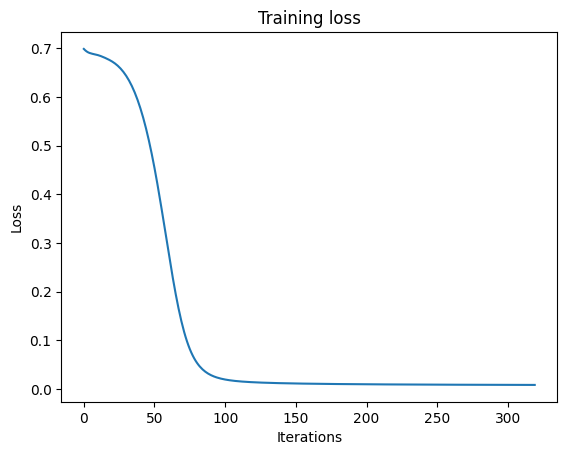

Processed 1000 samples...
Processed 2000 samples...
Processed 3000 samples...
Processed 4000 samples...
Processed 5000 samples...
Processed 6000 samples...
Processed 7000 samples...
Processed 8000 samples...
Processed 9000 samples...
TP=4775, TN=5200, FP=13, FN=12
Accuracy: 0.9975
Precision: 0.99728488
Recall: 0.99749321
F1-Score: 0.99738903
Specificity: 0.99750623


{'accuracy': 0.9975,
 'precision': 0.99728488,
 'recall': 0.99749321,
 'f1_score': 0.99738903,
 'specificity': 0.99750623,
 'confusion_matrix': {'TP': 4775, 'TN': 5200, 'FP': 13, 'FN': 12}}

In [29]:
configurable_model = ConfigurableNN(config_path="config.yaml")
configurable_model.to("cuda") if torch.cuda.is_available() else configurable_model.to("cpu")
configurable_model = train_model(configurable_model, X_train, y_train, X_val, y_val)
test(configurable_model.to("cpu"), X_test, y_test)

## Torch Kvantáló

Ugyanúgy dolgozok mint a fentinél. Fontos hogy ugyanazokkal a paraméterekkel hozzam létre a hálót, mint a FP32-es modell esetében a súlyok átmásolása miatt.

In [30]:
import torch
import torch.nn as nn
import numpy as np
import torch.optim as optim
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
import yaml
from pathlib import Path

class ConfigurableQuantizedNN(nn.Module):
    def __init__(self, config_path="config.yaml"):
        super(ConfigurableQuantizedNN, self).__init__()
        
        self.config = self.load_config(config_path)
        network_config = self.config['network']
        
        self.input_size = network_config['input_size']
        self.output_size = network_config['output_size']
        self.hidden_layers = network_config['hidden_layers']
        self.layer_sizes = network_config['layer_sizes']
        self.use_bias = network_config['use_bias']
        
        self.activation = self.get_activation(network_config['activation'])
        self.output_activation = self.get_activation(network_config['output_activation'])

        self.quant = torch.quantization.QuantStub()
        self.dequant = torch.quantization.DeQuantStub()
        
        self.layers = nn.ModuleList()
        self.build_layers()
    
    def load_config(self, config_path):
        if not Path(config_path).exists():
            raise FileNotFoundError(f"Konfigurációs fájl nem található: {config_path}")
        
        with open(config_path, 'r') as f:
            return yaml.safe_load(f)
    
    def get_activation(self, activation_name):
        activations = {
            'relu': nn.ReLU(),
            'sigmoid': nn.Sigmoid(),
            'tanh': nn.Tanh(),
            'leaky_relu': nn.LeakyReLU(),
            'softplus' : nn.Softplus(),
            'none': nn.Identity()
        }
        return activations.get(activation_name.lower(), nn.ReLU())
    
    def build_layers(self):

        # Input 
        if len(self.layer_sizes) < self.hidden_layers:
            # Ha nincs elég méret megadva, kiegészítjük az utolsó értékkel
            self.layer_sizes = self.layer_sizes + [self.layer_sizes[-1]] * (self.hidden_layers - len(self.layer_sizes))
        
        # Első réteg
        self.layers.append(nn.Linear(self.input_size, self.layer_sizes[0], bias=self.use_bias))
        
        for i in range(self.hidden_layers - 1):
            self.layers.append(nn.Linear(self.layer_sizes[i], self.layer_sizes[i+1], bias=self.use_bias))
        
        # Output réteg
        self.layers.append(nn.Linear(self.layer_sizes[-1], self.output_size, bias=self.use_bias))
        
    def forward(self, x):
        x = self.quant(x)
        for i in range(len(self.layers) - 1):
            x = self.activation(self.layers[i](x))
        x = self.output_activation(self.layers[-1](x))
        x = self.dequant(x)
        return x

configurable_quant_model = ConfigurableQuantizedNN(config_path="config.yaml").to(device="cpu")
configurable_quant_model.load_state_dict(configurable_model.state_dict())
configurable_quant_model.eval()

configurable_quant_model.qconfig = torch.ao.quantization.default_qconfig
quantconfigurable_quant_model_model = torch.ao.quantization.prepare(configurable_quant_model, inplace=True)
# Tesztadatok a kvantáláshoz
test(configurable_quant_model, X_test, y_test)
configurable_quant_model = torch.ao.quantization.convert(configurable_quant_model, inplace=True)
# Kvantált modell tesztelése
test(configurable_quant_model, X_test, y_test)


Processed 1000 samples...
Processed 2000 samples...
Processed 3000 samples...
Processed 4000 samples...
Processed 5000 samples...
Processed 6000 samples...
Processed 7000 samples...
Processed 8000 samples...
Processed 9000 samples...
TP=4775, TN=5200, FP=13, FN=12
Accuracy: 0.9975
Precision: 0.99728488
Recall: 0.99749321
F1-Score: 0.99738903
Specificity: 0.99750623


NotImplementedError: Could not run 'aten::softplus.out' with arguments from the 'QuantizedCPU' backend. This could be because the operator doesn't exist for this backend, or was omitted during the selective/custom build process (if using custom build). If you are a Facebook employee using PyTorch on mobile, please visit https://fburl.com/ptmfixes for possible resolutions. 'aten::softplus.out' is only available for these backends: [CPU, CUDA, Meta, BackendSelect, Python, FuncTorchDynamicLayerBackMode, Functionalize, Named, Conjugate, Negative, ZeroTensor, ADInplaceOrView, AutogradOther, AutogradCPU, AutogradCUDA, AutogradHIP, AutogradXLA, AutogradMPS, AutogradIPU, AutogradXPU, AutogradHPU, AutogradVE, AutogradLazy, AutogradMTIA, AutogradPrivateUse1, AutogradPrivateUse2, AutogradPrivateUse3, AutogradMeta, AutogradNestedTensor, Tracer, AutocastCPU, AutocastXPU, AutocastMPS, AutocastCUDA, FuncTorchBatched, BatchedNestedTensor, FuncTorchVmapMode, Batched, VmapMode, FuncTorchGradWrapper, Pyt

## Brevitas kvantáló

In [31]:
import torch
import torch.nn as nn
import brevitas.nn as qnn
from brevitas.quant import Int8ActPerTensorFloat, Int8WeightPerTensorFloat, SignedTernaryWeightPerTensorConst, SignedTernaryActPerTensorConst, Int8BiasPerTensorFixedPointInternalScaling, Int8WeightPerTensorFixedPoint, Int8ActPerTensorFixedPoint
from brevitas.quant.scaled_int import Int8BiasPerTensorFloatInternalScaling
import yaml
from pathlib import Path

class ConfigurableQuantNN_Brevitas(nn.Module):
    def __init__(self, config_path="config.yaml"):
        super().__init__()

        self.config = self.load_config(config_path)
        network_config = self.config["network"]
        quant_config = self.config.get("quantization", {})

        self.input_size = network_config["input_size"]
        self.output_size = network_config["output_size"]
        self.hidden_layers = network_config["hidden_layers"]
        self.layer_sizes = network_config["layer_sizes"]
        self.use_bias = network_config["use_bias"]

        self.act_quant_type = quant_config.get("act_quant", "Int8ActPerTensorFloat")
        self.weight_quant_type = quant_config.get("weight_quant", "Int8WeightPerTensorFloat")

        self.act_quant = self.get_act_quantizer(self.act_quant_type)
        self.weight_quant = self.get_weight_quantizer(self.weight_quant_type)

        self.activation_name = network_config["activation"]
        self.output_activation_name = network_config["output_activation"]

        self.layers = nn.ModuleList()
        self.build_layers()

    def load_config(self, config_path):
        if not Path(config_path).exists():
            raise FileNotFoundError(f"Konfig fájl nem található: {config_path}")
        with open(config_path, "r") as f:
            return yaml.safe_load(f)

    
    def get_act_quantizer(self, name):
        mapping = {
            "Int8ActPerTensorFloat": Int8ActPerTensorFloat,
            "SignedTernaryActPerTensorConst": SignedTernaryActPerTensorConst, 
            "Int8ActPerTensorFixedPoint" : Int8ActPerTensorFixedPoint,
        }
        return mapping[name]

    def get_weight_quantizer(self, name):
        mapping = {
            "Int8WeightPerTensorFloat": Int8WeightPerTensorFloat,
            "SignedTernaryWeightPerTensorConst": SignedTernaryWeightPerTensorConst,
            'Int8WeightPerTensorFixedPoint' : Int8WeightPerTensorFixedPoint,
        }
        return mapping[name]

    def get_activation(self, activation_name):
        activations = {
            "relu": lambda: qnn.QuantReLU(act_quant=self.act_quant),
            "sigmoid": lambda: qnn.QuantSigmoid(act_quant=self.act_quant, signed=False),
            "tanh": lambda: qnn.QuantTanh(act_quant=self.act_quant),
            "leaky_relu" : lambda: nn.LeakyReLU(),
            "softplus" : lambda: nn.Softplus(),
            "none": lambda: qnn.QuantIdentity(act_quant=self.act_quant),
            "hardtanh" : lambda: qnn.QuantHardTanh(act_quant=self.act_quant),
        }
        return activations.get(activation_name.lower(), lambda: qnn.QuantReLU(act_quant=self.act_quant))()

    # --- rétegek építése ---
    def build_layers(self):
        if len(self.layer_sizes) < self.hidden_layers:
            self.layer_sizes = self.layer_sizes + [self.layer_sizes[-1]] * (self.hidden_layers - len(self.layer_sizes))

        self.layers.append(qnn.QuantIdentity(act_quant=self.act_quant, return_quant_tensor=True))

        self.layers.append(
            qnn.QuantLinear(
                in_features=self.input_size,
                out_features=self.layer_sizes[0],
                weight_quant=self.weight_quant,
                bias=self.use_bias,
                bias_quant=Int8BiasPerTensorFixedPointInternalScaling,
            )
        )
        self.layers.append(self.get_activation(self.activation_name))

        for i in range(self.hidden_layers - 1):
            self.layers.append(
                qnn.QuantLinear(
                    in_features=self.layer_sizes[i],
                    out_features=self.layer_sizes[i + 1],
                    weight_quant=self.weight_quant,
                    bias=self.use_bias,
                    bias_quant=Int8BiasPerTensorFixedPointInternalScaling,
                )
            )
            self.layers.append(self.get_activation(self.activation_name))

        self.layers.append(
            qnn.QuantLinear(
                in_features=self.layer_sizes[-1],
                out_features=self.output_size,
                weight_quant=self.weight_quant,
                bias=self.use_bias,
                bias_quant=Int8BiasPerTensorFixedPointInternalScaling,
            )
        )
        self.layers.append(self.get_activation(self.output_activation_name))

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x*2
    
    def classify_image(self, image_path, output_path="output_heatmap.png", cmap_name="inferno"):

        self.eval()

        img = Image.open(image_path).convert('RGB')
        img_array = np.array(img, dtype=np.float32)
        img_array = (img_array - 127.5) / 127.5

        height, width, _ = img_array.shape
        output_array = np.zeros((height, width), dtype=np.float32)

        with torch.no_grad():
            for i in range(height):
                for j in range(width):
                    pixel = torch.tensor(img_array[i, j], dtype=torch.float32).unsqueeze(0).to("cuda")
                    output = self.forward(pixel).item()
                    output_array[i, j] = output
        
        # opcionalis
        output_array = np.clip(output_array, 0.0, 1.0)

        cmap = cm.get_cmap(cmap_name)
        heatmap = cmap(output_array)[:, :, :3]

        heatmap_img = Image.fromarray((heatmap * 255).astype(np.uint8))
        heatmap_img.save(output_path)

        print(f"[INFO] Hőtérkép elmentve ide: {output_path}")

        return output_array

configurable_brevitas_quant_model = ConfigurableQuantNN_Brevitas(config_path="config.yaml").to(device="cpu")

In [33]:
def copy_weights_from_fp(fp_model, brevitas_model):
    # A Brevitas modellbbe nem csak a rétegek számolódna bele, hanem az aktivációk is, ezért válogatni kell
    fp_linears = [m for m in fp_model.layers if isinstance(m, nn.Linear)]
    brevitas_linears = [m for m in brevitas_model.layers if isinstance(m, qnn.QuantLinear)]

    if len(fp_linears) != len(brevitas_linears):
        raise ValueError(f"Rétegek száma nem egyezik! FP={len(fp_linears)}, Brevitas={len(brevitas_linears)}")

    with torch.no_grad():
        for l_fp, l_q in zip(fp_linears, brevitas_linears):
            l_q.weight.data.copy_(l_fp.weight.data)
            if l_fp.bias is not None and l_q.bias is not None:
                l_q.bias.data.copy_(l_fp.bias.data)

copy_weights_from_fp(configurable_model, configurable_brevitas_quant_model)
configurable_brevitas_quant_model.eval()

calibration_data = X_train[:10000] 
test(configurable_brevitas_quant_model, X_test, y_test)

configurable_brevitas_quant_model.train()
with torch.no_grad():
    for i in range(min(100, len(calibration_data))):
        sample = calibration_data[i].unsqueeze(0)
        _ = configurable_brevitas_quant_model(sample)
        if i % 20 == 0:
            print(f"Kalibráció: {i}/100")
            
configurable_brevitas_quant_model.eval()
test(configurable_brevitas_quant_model, X_test, y_test)

Processed 1000 samples...
Processed 2000 samples...
Processed 3000 samples...
Processed 4000 samples...
Processed 5000 samples...
Processed 6000 samples...
Processed 7000 samples...
Processed 8000 samples...
Processed 9000 samples...
TP=4780, TN=5195, FP=18, FN=7
Accuracy: 0.9975
Precision: 0.99624844
Recall: 0.99853771
F1-Score: 0.99739176
Specificity: 0.99654709
Kalibráció: 0/100
Kalibráció: 20/100
Kalibráció: 40/100
Kalibráció: 60/100
Kalibráció: 80/100
Processed 1000 samples...
Processed 2000 samples...
Processed 3000 samples...
Processed 4000 samples...
Processed 5000 samples...
Processed 6000 samples...
Processed 7000 samples...
Processed 8000 samples...
Processed 9000 samples...
TP=4780, TN=5195, FP=18, FN=7
Accuracy: 0.9975
Precision: 0.99624844
Recall: 0.99853771
F1-Score: 0.99739176
Specificity: 0.99654709


{'accuracy': 0.9975,
 'precision': 0.99624844,
 'recall': 0.99853771,
 'f1_score': 0.99739176,
 'specificity': 0.99654709,
 'confusion_matrix': {'TP': 4780, 'TN': 5195, 'FP': 18, 'FN': 7}}

Súlyok kimentése fájlokba

In [ ]:
brevitas_linears = [m for m in configurable_brevitas_quant_model.layers if isinstance(m, qnn.QuantLinear)]

extract_params_hls(
    brevitas_linears,
    "brevitas_conf_params",
    backend="brevitas"
)
"""
extract_params(
    configurable_quant_model.layers,
    "torch_quant_conf_params", backend="torch_quant"
)
"""

'\nextract_params(\n    configurable_quant_model.layers,\n    "torch_quant_conf_params", backend="torch_quant"\n)\n'

In [ ]:
for X_v, y_v in zip(X_val[:10], y_val[:10]):
    X_v = X_v.unsqueeze(0)
    with torch.no_grad():
        fp_out = configurable_model(X_v).item()
        # torch_q_out = configurable_quant_model(X_v).item()
        brevitas_out = configurable_brevitas_quant_model(X_v).item()
        inputs = (X_v * 127.5) + 127.5
    print(f"Input: {inputs}, Elvárt: {y_v}, Valós: {y_v.item()}, FP: {fp_out:.6f},Brevitas quant: {brevitas_out:.6f}")

Input: tensor([[169., 165., 153.]]), Elvárt: tensor([0.]), Valós: 0.0, FP: 0.000117,Brevitas quant: 0.000000
Input: tensor([[154., 178.,  50.]]), Elvárt: tensor([1.]), Valós: 1.0, FP: 0.977476,Brevitas quant: 1.260960
Input: tensor([[179., 194.,   0.]]), Elvárt: tensor([1.]), Valós: 1.0, FP: 0.997621,Brevitas quant: 1.260960
Input: tensor([[179., 194.,   0.]]), Elvárt: tensor([1.]), Valós: 1.0, FP: 0.997621,Brevitas quant: 1.260960
Input: tensor([[133., 108.,  81.]]), Elvárt: tensor([0.]), Valós: 0.0, FP: 0.000000,Brevitas quant: 0.000000
Input: tensor([[178., 190.,   0.]]), Elvárt: tensor([1.]), Valós: 1.0, FP: 0.997123,Brevitas quant: 1.260960
Input: tensor([[182., 196.,   0.]]), Elvárt: tensor([1.]), Valós: 1.0, FP: 0.998099,Brevitas quant: 1.260960
Input: tensor([[105., 105., 106.]]), Elvárt: tensor([0.]), Valós: 0.0, FP: 0.000000,Brevitas quant: 0.000000
Input: tensor([[228., 240., 245.]]), Elvárt: tensor([0.]), Valós: 0.0, FP: 0.000000,Brevitas quant: 0.000000
Input: tensor([[149

Test dataset készítése és mentése

In [181]:
def save_dataset(X, y, filename_prefix="dataset"):
    X_scaled = (X * 256)
    y = y.numpy()

    np.savetxt(f"{filename_prefix}_X.txt", X_scaled.numpy(), fmt="%d", delimiter=", ")
    np.savetxt(f"{filename_prefix}_y.txt", y, fmt="%d", delimiter=", ")
    print(f"Dataset saved to {filename_prefix}_X.txt and {filename_prefix}_y.txt")
save_dataset(X_test[:1000], y_test[:1000], filename_prefix="val_dataset")

Dataset saved to val_dataset_X.txt and val_dataset_y.txt


## A kvantált forward pass modellezése

Segítségnek kigyűjtöm itt a háló paramétereit

In [36]:
brevitas_linears = [m for m in configurable_brevitas_quant_model.layers if isinstance(m, qnn.QuantLinear)]
for layer in brevitas_linears:
    print("Weights:")
    print(layer.int_weight())
    print(layer.quant_weight())
    print("Bias:")
    print(layer.int_bias())
    print(layer.quant_bias())
    print("\n")

print(X_test[0]*256)
print(configurable_brevitas_quant_model.layers[6].quant_act_scale().data.item())


Weights:
tensor([[  92,  113,  -65],
        [ 111,   87, -116],
        [  36,  -63,   97],
        [   7, -125,   78]], dtype=torch.int8)
QuantTensor(value=tensor([[ 1.4375,  1.7656, -1.0156],
        [ 1.7344,  1.3594, -1.8125],
        [ 0.5625, -0.9844,  1.5156],
        [ 0.1094, -1.9531,  1.2188]], grad_fn=<MulBackward0>), scale=tensor(0.0156, grad_fn=<DivBackward0>), zero_point=tensor(0.), bit_width=tensor(8.), signed_t=tensor(True), training_t=tensor(False))
Bias:
tensor([ 48,  47,  78, 108], dtype=torch.int8)
QuantTensor(value=tensor([0.7500, 0.7344, 1.2188, 1.6875], grad_fn=<MulBackward0>), scale=tensor(0.0156, grad_fn=<DivBackward0>), zero_point=tensor(0.), bit_width=tensor(8.), signed_t=tensor(True), training_t=tensor(False))


Weights:
tensor([[-22, -59,  75,  88],
        [ 65,  98, -32, -99],
        [-19, -23,  58,  75],
        [  9, -86,  86,  89]], dtype=torch.int8)
QuantTensor(value=tensor([[-0.3438, -0.9219,  1.1719,  1.3750],
        [ 1.0156,  1.5312, -0.5000, -

Ez a kód párhuzamosan futtat kettő forward pass-t, az egyikben floating point-os műveleteket használok, a másikban integer műveleteket. A gondolat az volt, hogy statikus scaling faktorokat és bitszélességeket használok, de az aktivációkban fellépő pontosságvesztés következtében dinamikusan kell kezelnem ezt is.

In [48]:
out1 = []
out2 = []

actfp = nn.Softplus()

beta=1/(256*64) # beta = 1/(input_scale*weight_scale)
actint = nn.Softplus(beta=beta)

beta2 = 1/(32*64)
actint2 = nn.Softplus(beta=beta2)

for i in range(4):
    acc1 = 0
    acc2 = 0
    for j in range(3):
        acc1 += (configurable_brevitas_quant_model.layers[1].weight.data[i][j] * X_test[0][j])                       
        acc2 += (configurable_brevitas_quant_model.layers[1].weight.data[i][j]*64 * (X_test[0][j]*256)) # 64 = 2^6 súly aktiváció scale; 256 = 2^8 input sclae
    out1.append(actfp(acc1 + configurable_brevitas_quant_model.layers[1].bias.data[i])) 
    x = (acc2 + configurable_brevitas_quant_model.layers[1].bias.data[i] * 64 * 256) # bias a réteg együttes scale szerint
    x = actint(x) # fent definiált aktivációs fv szintén a scale szerint
    print(x/(256*64)) # ellenőrzésképpen, hogy egyezik-e a fp értékkel visszaskálázom
    x = x / (512) # ezt a lépés határozza meg a kimenet scaling faktorát, ezt szeretném dinamikussá tenni, egy priority encoderrel gondoltam megoldani, out_sf = 14 - 9 = 5
    out2.append(x)

print(out1)
print(out2)
print('\n')


layer2out1 = []
layer2out2 = []

for i in range(4):
    acc1 = 0
    acc2 = 0
    for j in range(4):
        acc1 += (configurable_brevitas_quant_model.layers[3].weight.data[i][j] * out1[j])                      
        acc2 += (configurable_brevitas_quant_model.layers[3].weight.data[i][j]*64 * (out2[j])) # az out2 hozza magával az előző réteg kimenetének a sf-jét 2^5=32
    layer2out1.append(actfp(acc1 + configurable_brevitas_quant_model.layers[3].bias.data[i]))
    x = acc2 + configurable_brevitas_quant_model.layers[3].bias.data[i] * 32 * 64
    x = actint2(x)
    print(x/(32*64))
    layer2out2.append(x / (128)) # out_sf = 11 - 7 = 4


print(layer2out1)
print(layer2out2)

layer3out1 = []
layer3out2 = []


outfp = nn.Sigmoid()

print('\n')


def outint(x):
    beta = 16*64
    return beta/(1 + torch.exp(-x/beta)) 

for i in range(1):
    acc1 = 0
    acc2 = 0
    for j in range(4):
        acc1 += (configurable_brevitas_quant_model.layers[5].weight.data[i][j] * layer2out1[j])                      
        acc2 += (configurable_brevitas_quant_model.layers[5].weight.data[i][j]*64 * (layer2out2[j]))
    layer3out1.append(outfp(acc1 + configurable_brevitas_quant_model.layers[5].bias.data[i]))
    x = (acc2 + configurable_brevitas_quant_model.layers[5].bias.data[i] * 16 * 64)
    x = outint(x)
    print(x / (16*64))
    layer3out2.append(x)

print(layer3out1)
print(layer3out2)


tensor(3.0786)
tensor(2.9698)
tensor(1.2229)
tensor(0.8705)
[tensor(3.0786), tensor(2.9698), tensor(1.2229), tensor(0.8705)]
[tensor(98.5155), tensor(95.0347), tensor(39.1319), tensor(27.8551)]


tensor(0.8343)
tensor(6.1253)
tensor(0.9317)
tensor(0.7698)
[tensor(0.8343), tensor(6.1253), tensor(0.9317), tensor(0.7698)]
[tensor(13.3494), tensor(98.0051), tensor(14.9071), tensor(12.3163)]


tensor(0.9989)
[tensor(0.9989)]
[tensor(1022.8637)]
